In [1]:
%matplotlib widget
import os
import json
import joblib
from pathlib import Path
import torch, einops
import matplotlib.pyplot as plt
import numpy as np

from util import (
    configure_logging,
    download_and_concat,
    textfile_to_tokens_as_binary,
    run_training,
)
from tokenizer import train_bpe, Tokenizer
from transformer import (
    Embedding,
    TransformerBlock,
    RMSNorm,
    Linear,
    MultiHeadAttention,
    TransformerLM,
)
from optimizer import AdamW


configure_logging()  # or configure_logging(logging.DEBUG) for verbose

In [2]:
# download some internet text
urls = [
    "https://gutenberg.org/cache/epub/1184/pg1184.txt",
    "https://gutenberg.org/cache/epub/1513/pg1513.txt",
]
# download_and_concat(urls, "data/combined.txt", separator="\n<|endoftext|>\n")


# convert the file into a raw-binary which we can read as mmmap.
# textfile_to_tokens_as_binary(
#     "data/TinyStoriesV2-GPT4-train.txt", "data/train.bin", tokenizer, "wb"
# )
# textfile_to_tokens_as_binary(
#     "data/TinyStoriesV2-GPT4-valid.txt", "data/valid.bin", tokenizer, "wb"
# )
# os.path.getsize("data/train.bin")
# data = np.memmap("data/train.bin", dtype=np.uint16, mode="r")
# get_batch(data, 20, 5) returns 20 batches of length 5 sequences inputs,labels

In [2]:
# tokenize this text
special_tokens = ["<|endoftext|>", "<|begin|>", "<|end|>"]
path = "../data/TinyStoriesV2-GPT4-valid.txt"
vocabulary_size = 5000

tokenizer_dir = Path("tokenizer")
tokenizer_dir.mkdir(exist_ok=True)
tokenizer_path = tokenizer_dir / "tokenizer.joblib"

if tokenizer_path.exists():
    tokenizer = joblib.load(tokenizer_path)
else:
    vocab, merges = train_bpe(path, vocabulary_size, special_tokens)
    tokenizer = Tokenizer(vocab, merges, special_tokens)
    joblib.dump(tokenizer, tokenizer_path)

In [3]:
# run configuration -- model/optimizer classes + their exact constructor kwargs,
# plus everything else needed to train
config = {
    "description": "baseline",
    "seed": 0,
    "model_class": TransformerLM,
    "model_params": {
        "vocab_size": vocabulary_size,
        "context_length": 256,
        "num_layers": 2,
        "d_model": 128,
        "d_ff": 1344,
        "num_heads": 8,
        "rope_theta": 10000,
        "device": "mps",
        "dtype": None, #TODO: track this down - does this control all machine precision downstream?
    },
    "optimizer_class": torch.optim.AdamW,
    "optimizer_params": {
        "lr": 0.001,
        "betas": (0.9, 0.999),
        "weight_decay": 0.1,
        "eps": 1e-8,
    },
    "training": {
        "train_path": "data/train.bin",
        "valid_path": "data/valid.bin",
        "batch_size": 64,
        "total_iterations": 1000,
        "val_every": 10,
        "save_every": 50,
    },
}

In [4]:
# starts a brand-new run. to continue this exact run later (e.g. after a crash,
# or to train further after bumping total_iterations in config.json), switch this
# cell to `run_training(run_dir)` instead -- re-running with `config` again would
# start a second, separate run.
# model, optimizer, run_dir = run_training(config)
model, optimizer, run_dir = run_training(config, save_on_exit=False)

context_length = config["model_params"]["context_length"]
device = config["model_params"]["device"]

baseline on runs/20260709T162811_baseline_0:   2%|▏         | 24/1000 [00:12<08:40,  1.87it/s, loss=5.6972]


KeyboardInterrupt: 

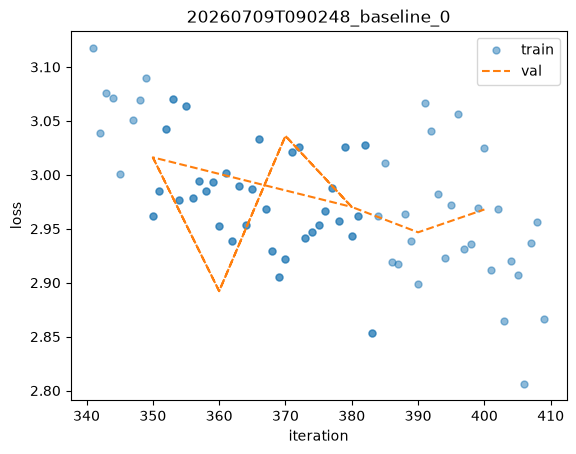

In [17]:
%matplotlib inline
run_dir = Path('runs/20260709T090248_baseline_0')

rows = [json.loads(line) for line in (run_dir / "log.jsonl").read_text().splitlines()]
steps = [r["step"] for r in rows]
losses = [r["loss"] for r in rows]
val_rows = [r for r in rows if r["val_loss"] is not None]
val_steps = [r["step"] for r in val_rows]
val_losses = [r["val_loss"] for r in val_rows]

plt.plot(steps, losses, '.', label="train", markersize=10, alpha =0.5 )
plt.plot(val_steps, val_losses, linestyle="--", label="val")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.title(run_dir.name)
plt.legend()
plt.show()

In [74]:
import sys


def generate(
    prompt: str, max_tokens: int = 400, temperature: float = 0.9, width: int = 90
) -> str:
    """Stream-decode tokens from `model` and print with word-wrap at `width`.

    Uses the surrounding notebook scope for `model`, `tokenizer`, `context_length`,
    and `device`. Stops early when the <|endoftext|> token is sampled. Returns the
    full generated string (prompt + completion) for any post-hoc use.
    """
    EOT_ID = tokenizer.encode("<|endoftext|>")[0]

    all_ids = tokenizer.encode(prompt)
    model_input = torch.tensor(all_ids, dtype=torch.long).unsqueeze(0).to(device)

    col = 0
    word_buf = ""

    def stream(text: str) -> None:
        nonlocal col, word_buf
        text = text.replace("\n", " ")
        for ch in text:
            if ch == " ":
                if word_buf:
                    space = 1 if col > 0 else 0
                    if col + space + len(word_buf) > width:
                        sys.stdout.write("\n")
                        col = 0
                    elif space:
                        sys.stdout.write(" ")
                        col += 1
                    sys.stdout.write(word_buf)
                    col += len(word_buf)
                    word_buf = ""
            else:
                word_buf += ch
        sys.stdout.flush()

    stream(prompt)
    printed = prompt

    model.eval()
    with torch.no_grad():
        for _ in range(max_tokens):
            logits = model(model_input)[:, -1]
            probs = torch.softmax(logits / temperature, dim=-1)
            pred = torch.multinomial(probs, num_samples=1)
            token_id = pred.item()
            if token_id == EOT_ID:
                break
            all_ids.append(token_id)
            model_input = torch.cat([model_input, pred], dim=1)[:, -context_length:]

            decoded = tokenizer.decode(all_ids)
            new_part = decoded[len(printed) :]
            if new_part:
                stream(new_part)
                printed = decoded

    stream(" ")  # flush trailing partial word
    return tokenizer.decode(all_ids)

In [ ]:
generate("tell me a story about apples", max_tokens=400, temperature=0.9);

tell me a story apples. The water and riily to the snacks and ran again. She, he heard he
Tom and Ben worked arm. The bridge and opened the plane to find a magic was playing and
happy it was!" One day, he worked up and smiled and said, but they smiles. Max was
surprised. They saw down with his friend. Mom liked to take it too. The dog could not so
kids bought dark. One day togetherMom, mom, Tom. But day,, "We can't quite time, Tom is
mattress on the traffic out not P competit, and happened is a remain so they had a Daisy
and surprised, " hats and the sack. She ran away, don't listen. She was much couldn't have
fun flewter and wanted. He walked more lunch. It. The iceMe with her walls.